In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Raw data

In [10]:
barra_file = '/g/data/xv83/dbi599/rba/Rx5day/BARRA-R2/Rx5day_yr_BARRA-R2_aus-states-cities_1980-2024.csv'
df_barra = pd.read_csv(barra_file)

In [11]:
def plot_location(model, experiment, location, start_year=1950):
    """Scatterplot for a given location"""

    infile = f'/g/data/xv83/dbi599/rba/Rx5day/{model}/{experiment}/rx5day_yr_{model}_{experiment}_ensemble_aus-states-cities_1850-2100.csv'
    df = pd.read_csv(infile)
    fig, ax = plt.subplots(figsize=[15,7])
    sns.scatterplot(
        ax=ax,
        data=df[df['year'] >= start_year],
        x='year',
        y=location,
        hue='run',
    )
    sns.scatterplot(
        ax=ax,
        data=df_barra,
        x='year',
        y=location,
        color='black',
        label='BARRA-R2',
    )
    ax.set_ylabel('Rx5day')
    ax.set_title(f'{model} - {experiment} - {location}')
    ax.legend(bbox_to_anchor=(1.05, 1.0), ncol=2)
    ax.grid()
    plt.show()

In [14]:
def plot_dist(model, experiment, location, start_year=1950, end_year=2014):
    """Histogram for a given location"""

    infile = f'/g/data/xv83/dbi599/rba/Rx5day/{model}/{experiment}/rx5day_yr_{model}_{experiment}_ensemble_aus-states-cities_1850-2100.csv'
    df = pd.read_csv(infile)
    df_ref = df[(df['year'] >= start_year) & (df['year'] <= end_year)]
    fig, ax = plt.subplots()
    sns.histplot(
        ax=ax,
        data=df_ref,
        x=location,
    )
    ax.set_ylabel('Rx5day')
    ax.set_title(f'{model} - {experiment} - {location}')
    ax.grid()
    plt.show()

#### Individual models

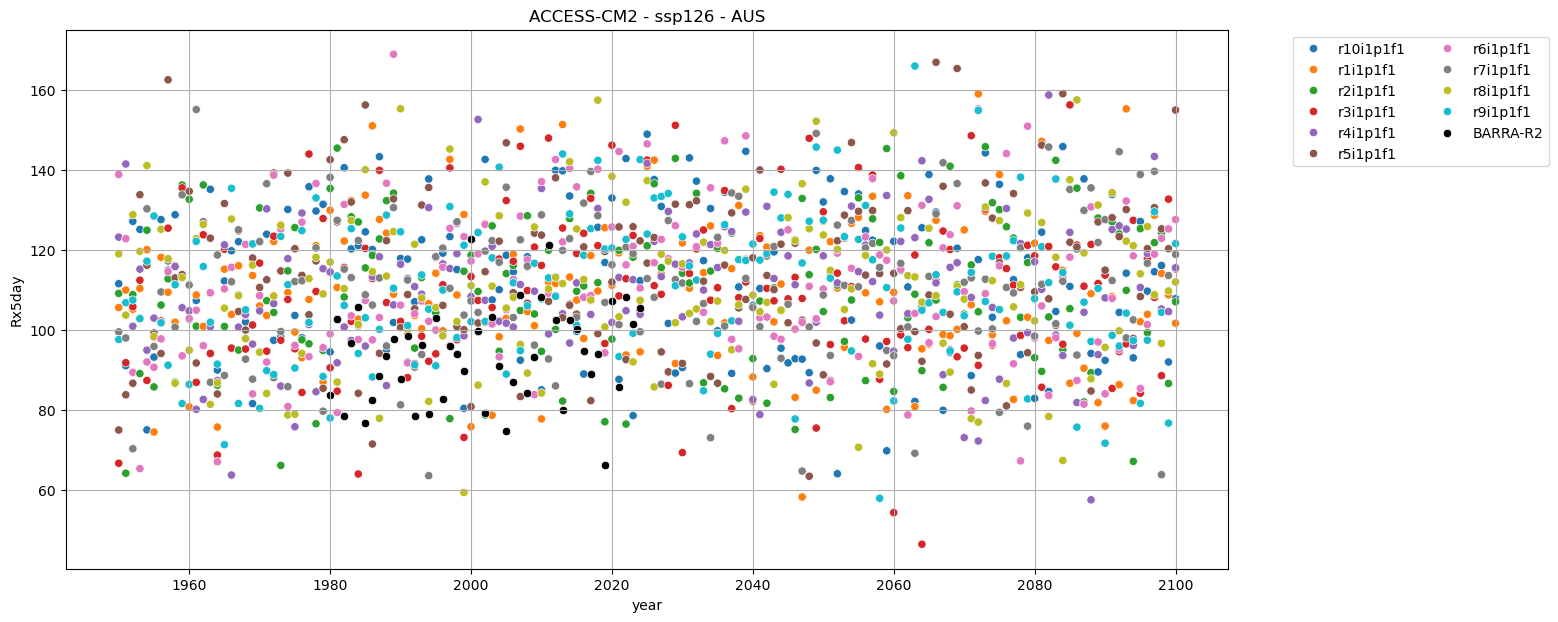

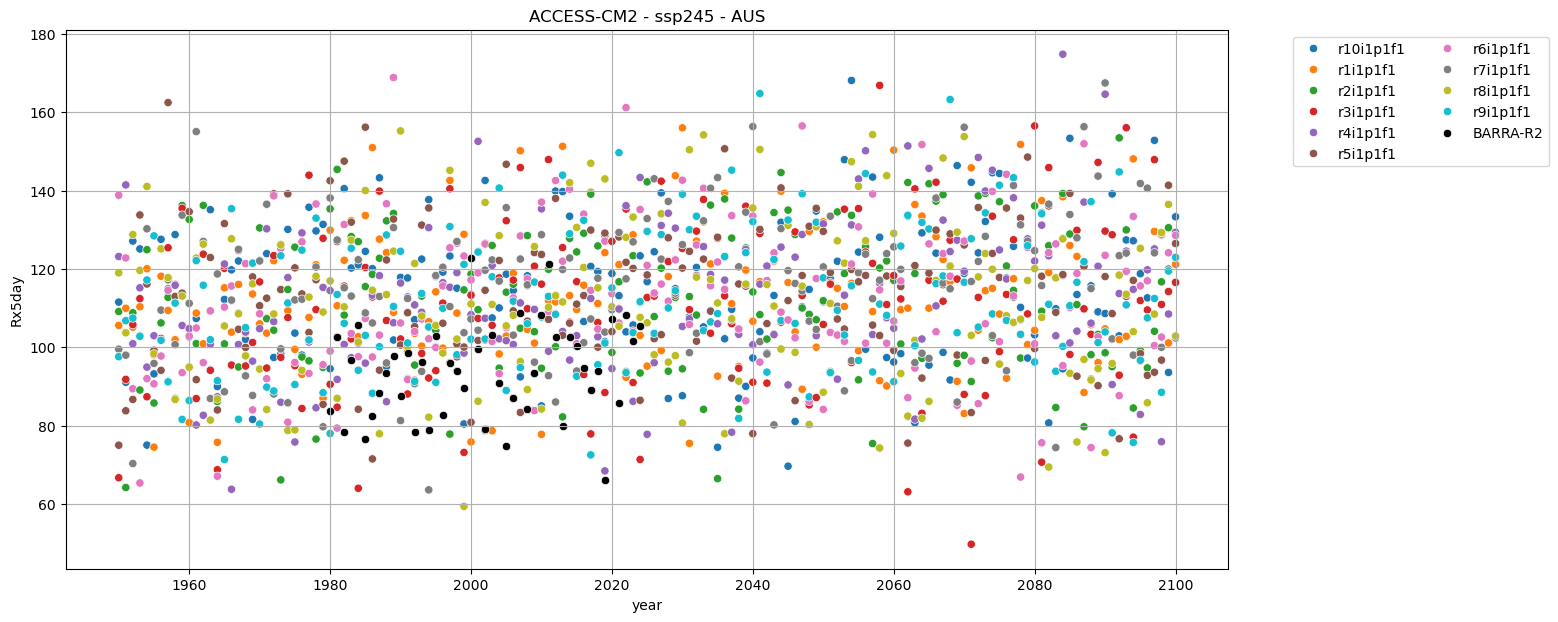

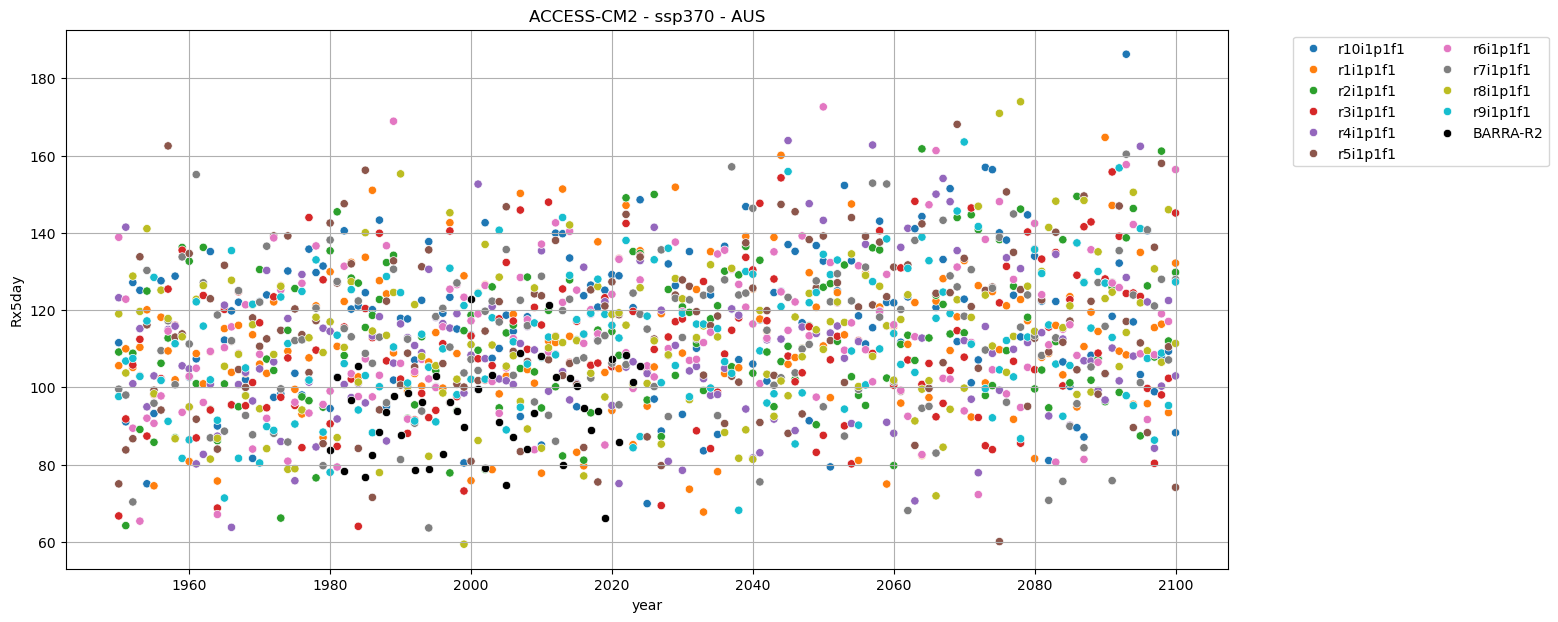

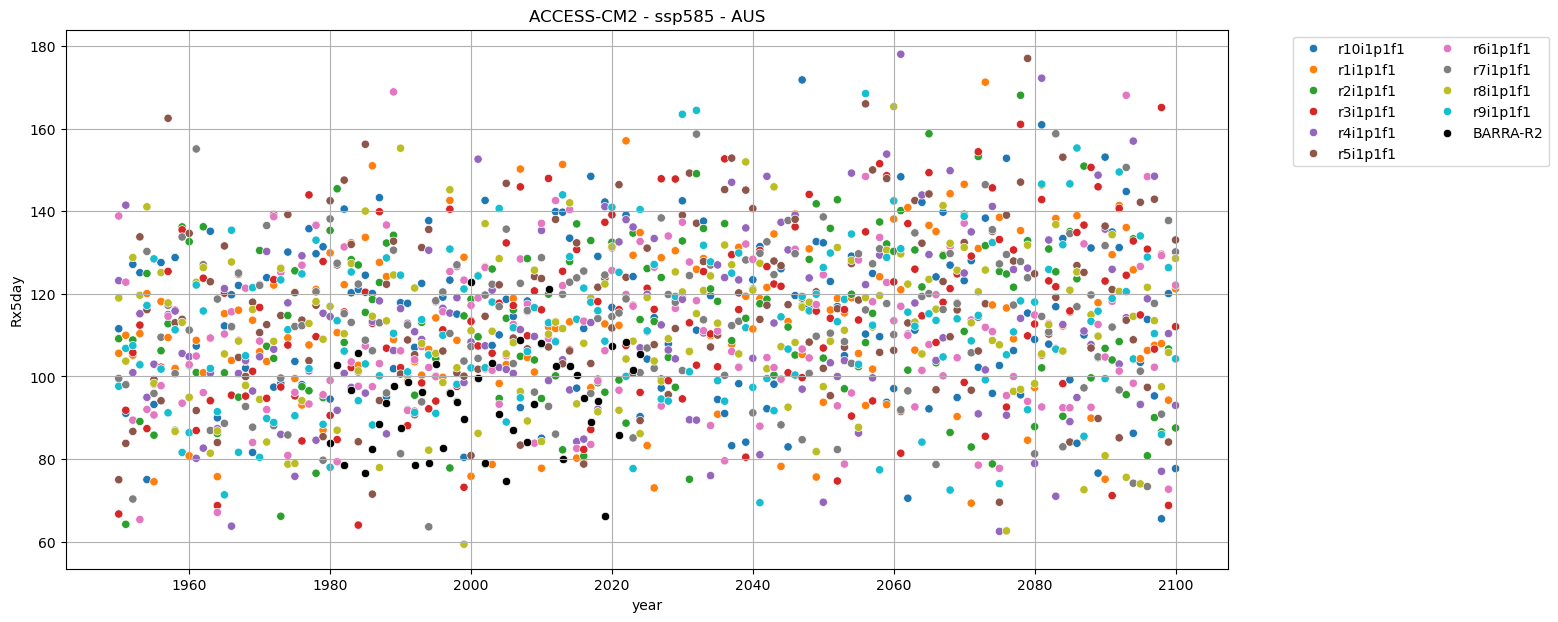

In [15]:
#for model in ['ACCESS-ESM1-5', 'ACCESS-CM2', 'CanESM5', 'IPSL-CM6A-LR', 'MPI-ESM1-2-LR', 'UKESM1-0-LL']:
for model in ['ACCESS-CM2']:
    for exp in ['ssp126', 'ssp245', 'ssp370', 'ssp585']:
        plot_location(model, exp, 'AUS')

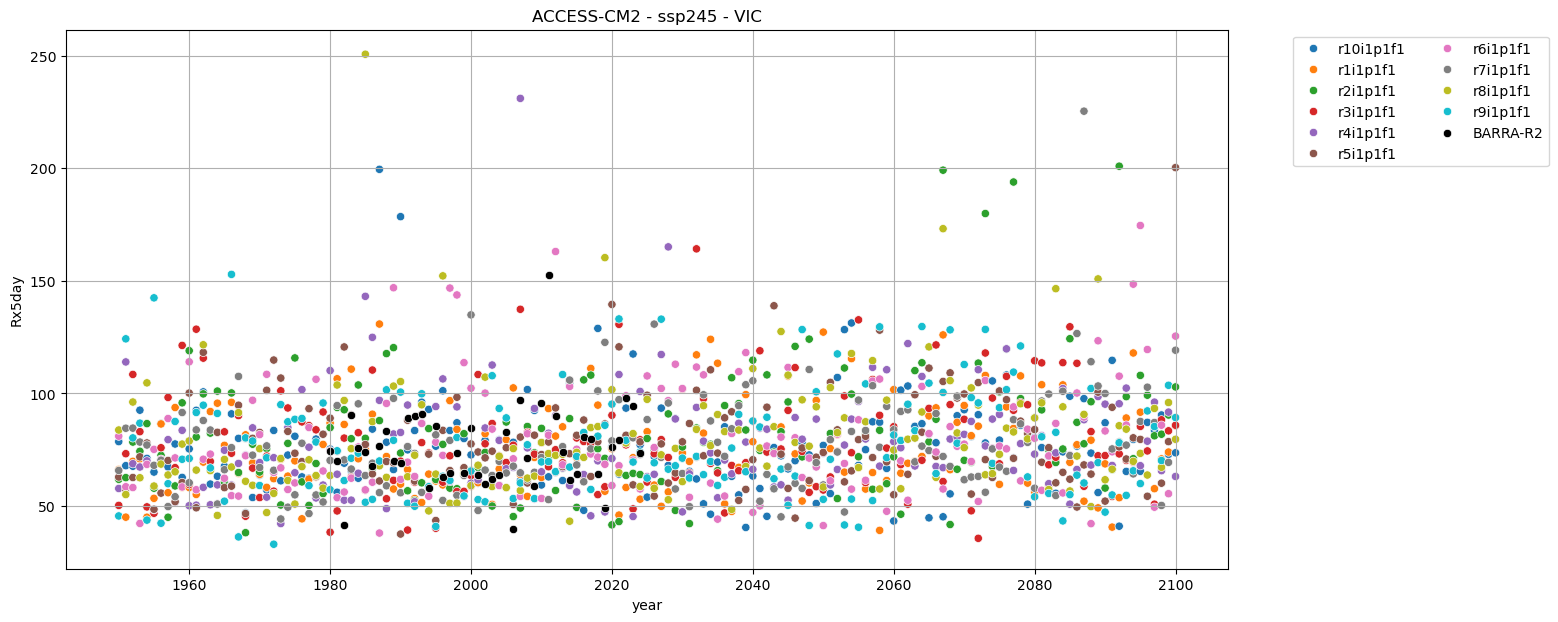

In [16]:
plot_location('ACCESS-CM2', 'ssp245', 'VIC')

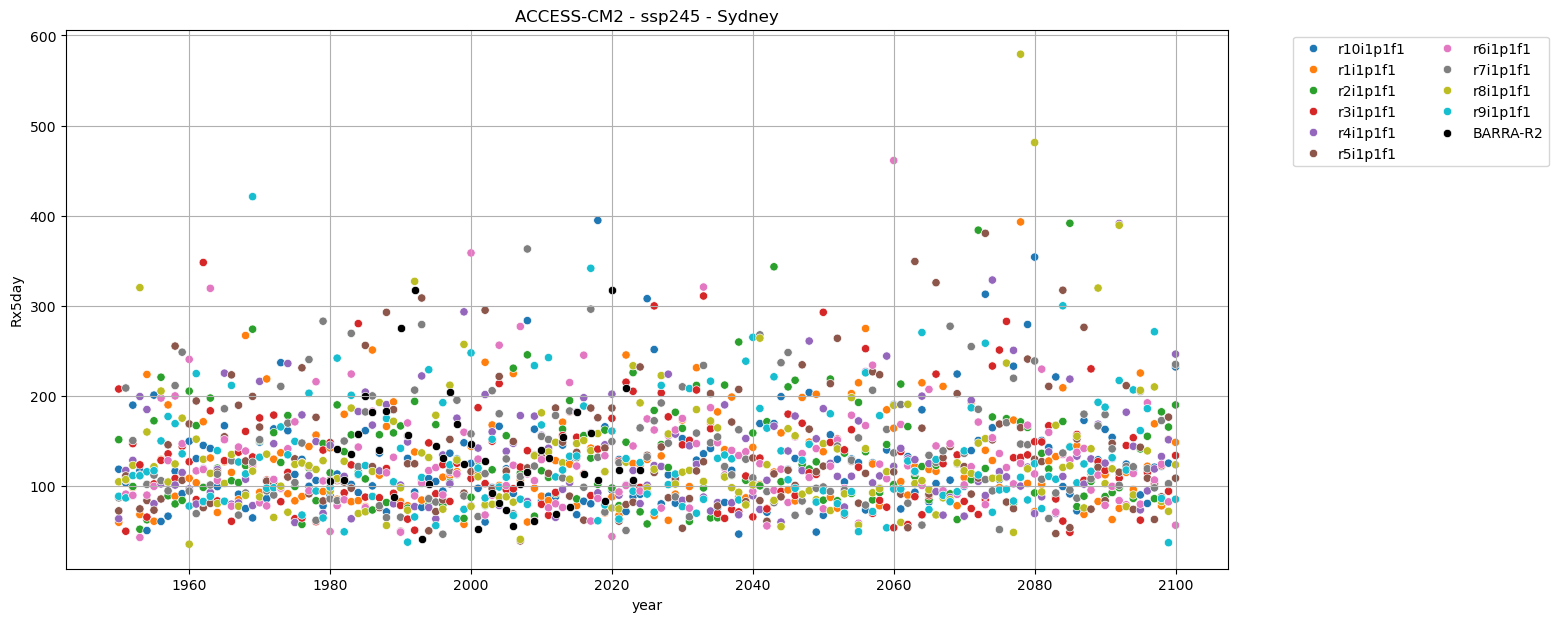

In [17]:
plot_location('ACCESS-CM2', 'ssp245', 'Sydney')

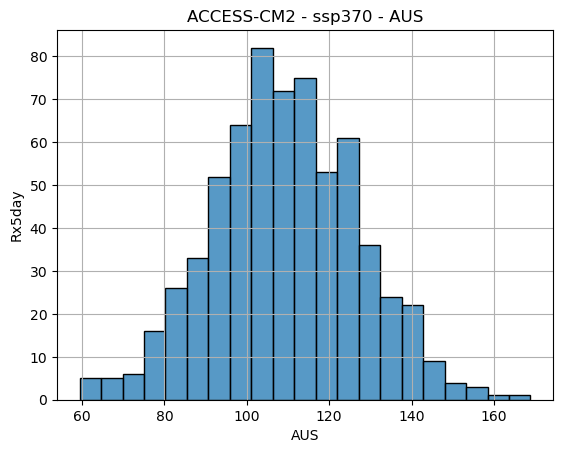

In [18]:
plot_dist('ACCESS-CM2', 'ssp370', 'AUS')

## Ensemble

In [19]:
colors = {
    'ACCESS-CM2': 'tab:blue',
    'ACCESS-ESM1-5': 'tab:green',
    'CanESM5': 'tab:orange',
    'EC-Earth3': 'tab:red',
    'MPI-ESM1-2-LR': 'tab:purple',
    'IPSL-CM6A-LR': 'tab:brown',
    'UKESM1-0-LL': 'tab:pink',
    'EC-Earth3-Veg': 'tab:gray',
}

linestyles = {
    'ssp585': 'solid',
    'ssp370': 'dashed',
    'ssp245': 'dashdot',
    'ssp126': 'dotted',
}

return_conversion = {
    '1-in-50 year': '98-0p',
    '1-in-40 year': '97-5p',
    '1-in-30 year': '96-7p',
    '1-in-20 year': '95-0p',
    '1-in-10 year': '90-0p',
}

def plot_ensemble_odds(
    models,
    experiments,
    location,
    return_period,
):
    """Ensemble odds of a year higher than a given return period for a given location."""

    # Plot
    fig, ax = plt.subplots()
    plabel = return_conversion[return_period]
    for model in models:
        for experiment in experiments:
            infile = f'/g/data/xv83/dbi599/rba/Rx5day/{model}/{experiment}/rx5day_yr_{plabel}-likelihood_{model}_{experiment}_aus-states-cities_1860-2091.csv'
            df = pd.read_csv(infile, header=7, index_col='year')
            df = df[location]
            sns.lineplot(
                ax=ax,
                data=df,
                label=f'{model} ({experiment})',
                color=colors[model],
                linestyle=linestyles[experiment],
            )
    ax.set_xlabel('year')
    ax.set_ylabel(f'odds of exceeding {return_period} event (%)') 
    ax.set_title(f'Rx5day - {location}')
    ax.legend(bbox_to_anchor=(1.05, 1), ncols=2, fontsize='small')
    ax.grid()
    plt.show()

    # Supporting info
    for model in models:
        pfile = f'/g/data/xv83/dbi599/rba/Rx5day/{model}/{experiments[0]}/rx5day_yr_percentiles_{model}_{experiments[0]}_aus-states-cities_1950-2014.csv' 
        pdf = pd.read_csv(pfile, header=6, index_col='percentile')
        pdf = pdf[location]
        p = float(plabel[0:-1].replace('-', '.'))
        pval = pdf.loc[p]
        print(f'{return_period} event, {model}: {pval}')
        
    obs = pd.read_csv(
        '/g/data/xv83/dbi599/rba/Rx5day/BARRA-R2/Rx5day_yr_BARRA-R2_aus-states-cities_1980-2024.csv',
        index_col='year',
    )
    print('Top 10 years in BARRA-R2:')
    print(obs[location].sort_values(ascending=False)[0:15])

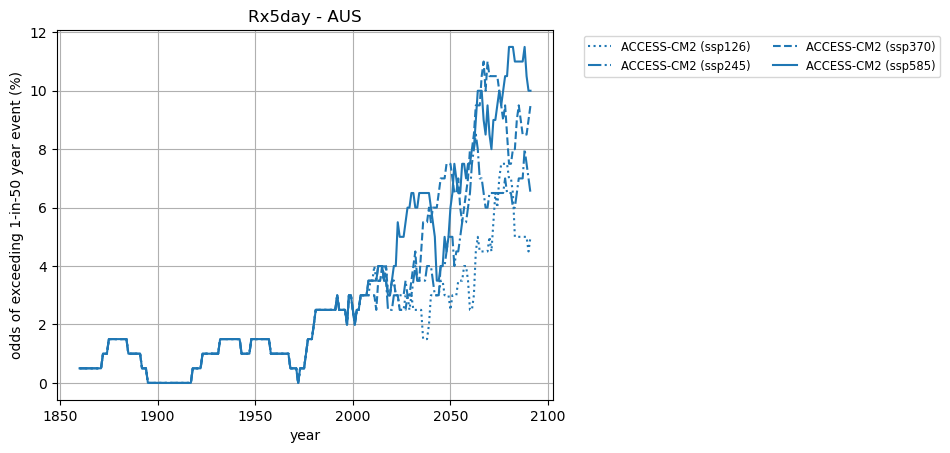

1-in-50 year event, ACCESS-CM2: 145.44
Top 10 years in BARRA-R2:
year
2000    122.76
2011    121.27
2007    108.84
2022    108.26
2010    108.14
2020    107.33
1984    105.63
2024    105.47
2003    103.17
1995    102.92
1981    102.69
2012    102.60
2014    102.54
2023    101.50
2015    100.32
Name: AUS, dtype: float64


In [20]:
plot_ensemble_odds(
#    ['ACCESS-ESM1-5', 'ACCESS-CM2', 'CanESM5', 'IPSL-CM6A-LR', 'MPI-ESM1-2-LR', 'UKESM1-0-LL'],
    ['ACCESS-CM2',],
    ['ssp126', 'ssp245', 'ssp370', 'ssp585'],
    'AUS',
    '1-in-50 year',
)

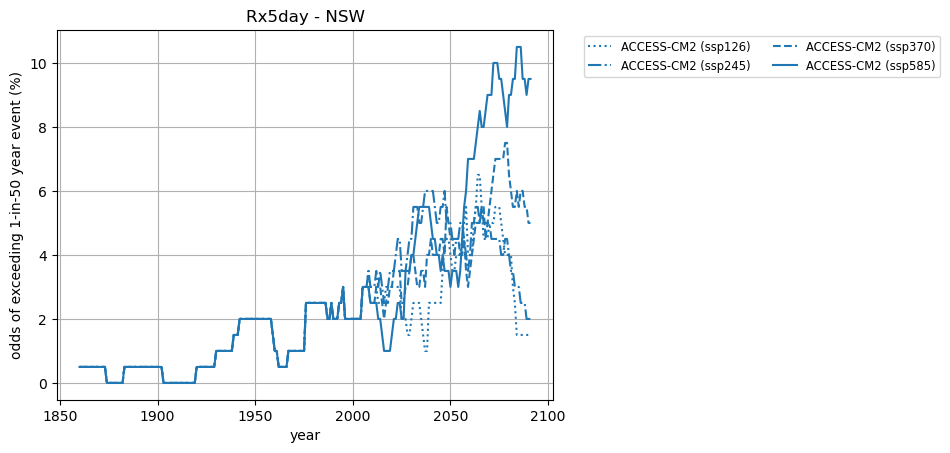

1-in-50 year event, ACCESS-CM2: 160.03
Top 10 years in BARRA-R2:
year
2012    135.29
1988    119.36
2011    114.76
1984    111.78
1990    108.28
2000    105.97
2020    105.24
1995    105.21
1989    103.86
2021    103.44
2022    103.39
2010    101.91
1992     99.33
1991     93.45
1996     93.39
Name: NSW, dtype: float64


In [21]:
plot_ensemble_odds(
#    ['ACCESS-ESM1-5', 'ACCESS-CM2', 'CanESM5', 'IPSL-CM6A-LR', 'MPI-ESM1-2-LR', 'UKESM1-0-LL'],
    ['ACCESS-CM2',],
    ['ssp126', 'ssp245', 'ssp370', 'ssp585'],
    'NSW',
    '1-in-50 year',
)

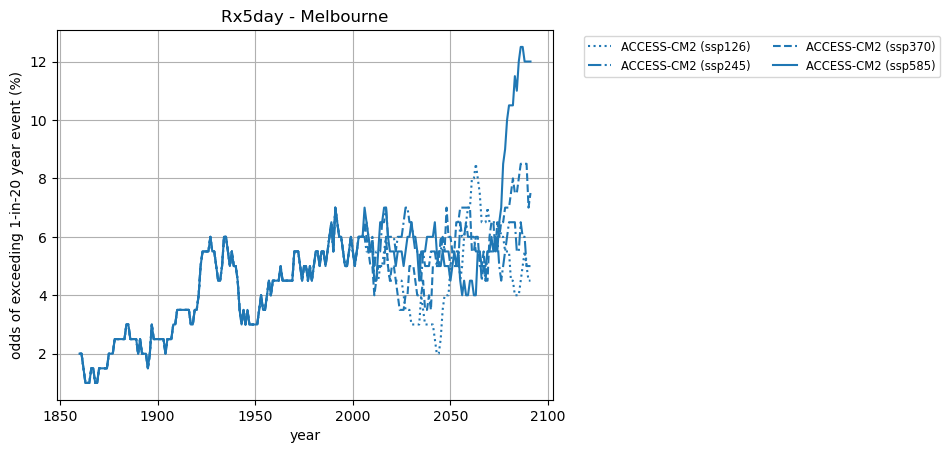

1-in-20 year event, ACCESS-CM2: 127.31
Top 10 years in BARRA-R2:
year
2005    144.33
2001    132.45
2016    111.83
1984    108.25
2011    105.49
2022    104.19
1987    100.07
1991     95.34
2017     92.55
1988     89.22
2024     89.07
2000     87.32
1999     87.06
1989     85.57
2010     84.30
Name: Melbourne, dtype: float64


In [22]:
plot_ensemble_odds(
#    ['ACCESS-ESM1-5', 'ACCESS-CM2', 'CanESM5', 'IPSL-CM6A-LR', 'MPI-ESM1-2-LR', 'UKESM1-0-LL'],
    ['ACCESS-CM2',],
    ['ssp126', 'ssp245', 'ssp370', 'ssp585'],
    'Melbourne',
    '1-in-20 year',
)